# % of Bike Commuters vs Bike Network Quality (Connectivity of LTS < 2 Subnetwork)

In [1]:
%%capture
pip install osmnx

In [2]:
%%capture
pip install --pre pycen==0.1.0a4

In [3]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import geopandas as gpd
import osmnx as ox
import networkx as nx
from pycen import acquire

plt.style.use('seaborn-v0_8')

city = ["San Jose","Berkeley"] ### CHANGE THIS TO TRY OTHER CITIES. FIRST MAKE SURE THAT YOU HAVE DOWNLOADED THE QUALITY CSV FOR ALL OF THEM
#county= ['Santa Clara','Alameda'] #not used
state = "California"

PLACE = "%s, %s, USA"%(city,state)
YEARS = [2014, 2019] ### CHANGE THIS TO TRY OTHER YEARS
DATASET = "acs5"

variables = {
    "B08301_001E": "workers_total",
    "B08301_008E": "bike_commute"
}

print("Libraries imported.")

Libraries imported.


## 1. Download ACS bike commute share for city tracts

We pull tract-level data for two years and compute the percentage of workers who commute by bicycle.

We are going to iterate over every city in the given list of cities above. For each city, we import the census data including bike ridership for the two given years, import the csv file with the corresponding network analysis, and merge into one dataframe by census tract id. Then, we concatenate the dataframe to a larger combined dataframe that includes all cities.

In [27]:
tracts=pd.DataFrame()
for c in city:
    tracts_by_year = []
    for year in YEARS:
        gdf = acquire.get_censhp(
            variables=variables,
            geography="tract",
            place="%s"%c,
            state="CA",
            year=year,
            dataset=DATASET,
            add_area=True
        )
        gdf.replace(-666666666, np.nan, inplace=True)
        gdf["pct_bike_%s"%year] = gdf["bike_commute"] / gdf["workers_total"] * 100
        #gdf["year"] = year
        gdf['city'] = c
        tracts_by_year.append(gdf.to_crs("EPSG:4326"))
    #tracts_by_year = gpd.GeoDataFrame(pd.concat(tracts_by_year, ignore_index=True), crs="EPSG:4326")
    
    gdf_2014=tracts_by_year[0].reset_index()
    gdf_2019=tracts_by_year[1].reset_index()
    
    tracts_c = gpd.GeoDataFrame(gdf_2014)
    
    pct_bike_yr1,pct_bike_yr2='pct_bike_%s'%YEARS[0],'pct_bike_%s'%YEARS[1]
    tracts_c=pd.merge(tracts_c,gdf_2019[['GEOID',pct_bike_yr2]],on='GEOID')

    tracts_c['GEOID']=tracts_c['GEOID'].astype('int') ## make sure the tract id is an int so it is possible to merge with network quality

    bike_network_quality = pd.read_csv('data/%s_network_quality_metrics.csv'%c) ## Import csv of bike quality metrics by census tract (calculated in other notebooks)

    common_columns = tracts_c.drop(['index',pct_bike_yr1,pct_bike_yr2, 'workers_total', 'bike_commute', 'area_sqkm','city'],axis=1).columns
    quality_variable_columns = bike_network_quality.drop(['B19001_001E','Unnamed: 0','nodes', 'edges', 'nodes_lts1', 'edges_lts1', 'nodes_lts2',
       'edges_lts2'],axis=1).drop(common_columns,axis=1).columns ## 3. Only inclue relevant unique columns from the network quality dataframe (don't need duplicated census geometry data)
    
    ridership_quality_combined = pd.merge(tracts_c,bike_network_quality[np.append(quality_variable_columns,'GEOID')], on='GEOID') #Merge all network quality columns to the ridership dataframe by tract id
    
    tracts =pd.concat([tracts,ridership_quality_combined]) ## Add all combined data (census + network quality) from this city to the dataframe with all cities
    
tracts['pct_change']=tracts[pct_bike_yr2]-tracts[pct_bike_yr1]
    
    #tracts=pd.merge(tracts,gdf_2019['pct_bike_2019'],on='')

Resolving geography...
  State: California (CA, FIPS: 06)
Loading from cache: pycen_cache/api/acs5_2014_tract_06__07ae958225a92c0b.csv
Loading boundaries from cache...
Merging data...
Clipping to place: San Jose
Fetching boundaries...
Resolving geography...
  State: California (CA, FIPS: 06)
Loading from cache: pycen_cache/api/acs5_2019_tract_06__60e657f1e70e8a23.csv
Loading boundaries from cache...
Merging data...
Clipping to place: San Jose
Fetching boundaries...
Resolving geography...
  State: California (CA, FIPS: 06)
Loading from cache: pycen_cache/api/acs5_2014_tract_06__07ae958225a92c0b.csv
Loading boundaries from cache...
Merging data...
Clipping to place: Berkeley
Fetching boundaries...
Resolving geography...
  State: California (CA, FIPS: 06)
Loading from cache: pycen_cache/api/acs5_2019_tract_06__60e657f1e70e8a23.csv
Loading boundaries from cache...
Merging data...
Clipping to place: Berkeley
Fetching boundaries...


In [29]:
tracts

,index,STATEFP,COUNTYFP,TRACTCE,AFFGEOID,GEOID,NAME,LSAD,ALAND,AWATER,...,accessible_alpha_lts1,accessible_cycles_lts1,accessible_component_share_lts1,subgraph_inverse_lts1,accessible_beta_lts2,accessible_alpha_lts2,accessible_cycles_lts2,accessible_component_share_lts2,subgraph_inverse_lts2,pct_change
0,552,06,085,500400,1400000US06085500400,6085500400,5004,CT,1005368,0,...,0.033943,13.0,0.577320,0.034483,1.055556,0.043239,157,0.846535,0.017857,0.000000
1,553,06,085,501300,1400000US06085501300,6085501300,5013,CT,747097,0,...,0.009799,20.0,0.821114,0.041667,1.081848,0.041867,1386,0.988402,0.032258,-0.245459
2,554,06,085,502201,1400000US06085502201,6085502201,5022.01,CT,969615,0,...,0.016627,21.0,0.331230,0.024390,1.030110,0.024464,138,0.797733,0.018868,0.464481
3,555,06,085,502907,1400000US06085502907,6085502907,5029.07,CT,1251551,0,...,0.026667,2.0,0.275000,0.050000,1.085907,0.044621,835,0.786836,0.032258,0.000000
4,556,06,085,503204,1400000US06085503204,6085503204,5032.04,CT,1434115,0,...,0.000000,0.0,0.630435,0.062500,1.081341,0.041881,1391,0.985189,0.025000,-4.130546
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
28,7578,06,001,423800,1400000US06001423800,6001423800,4238,CT,1072450,0,...,0.023705,785.0,0.964432,0.045455,1.076060,0.038292,2218,0.994096,0.066667,0.000000
29,7818,06,001,421300,1400000US06001421300,6001421300,4213,CT,1106644,0,...,0.024115,777.0,0.991187,0.055556,1.076107,0.038385,2222,0.994714,0.052632,0.794764
30,7819,06,001,422600,1400000US06001422600,6001422600,4226,CT,1699288,0,...,0.022244,847.0,0.838769,0.003390,1.064437,0.036681,2270,0.930457,0.003623,0.000000
31,8033,06,001,421600,1400000US06001421600,6001421600,4216,CT,1333491,0,...,0.024072,811.0,0.947946,0.027778,1.076046,0.038337,2218,0.995264,0.055556,0.053677


In [ ]:
# nodes_in_tract = gpd.sjoin(
#     nodes_gdf,
#     tracts[["geometry"]],
#     how="inner",
#     predicate="within"
# )
# centrality_by_tract = nodes_in_tract.groupby("index_right")["betweenness"].mean()
# tracts["betweenness"] = centrality_by_tract
# tracts["betweenness"] = tracts["betweenness"].fillna(0)

# print(f"Tracts with centrality values: {tracts['betweenness'].gt(0).sum()} / {len(tracts)}")


## 4. Correlation Plot for all quality variables

In [30]:
import seaborn as sns

In [31]:
#correlation=ridership_quality_combined[np.append(quality_variable_columns,'pct_change')].corr()
#sns.heatmap(correlation)

In [32]:
#sns.set_theme(style="ticks")

#sns.pairplot(ridership_quality_combined[np.append(quality_variable_columns,'pct_change')])

<Axes: >

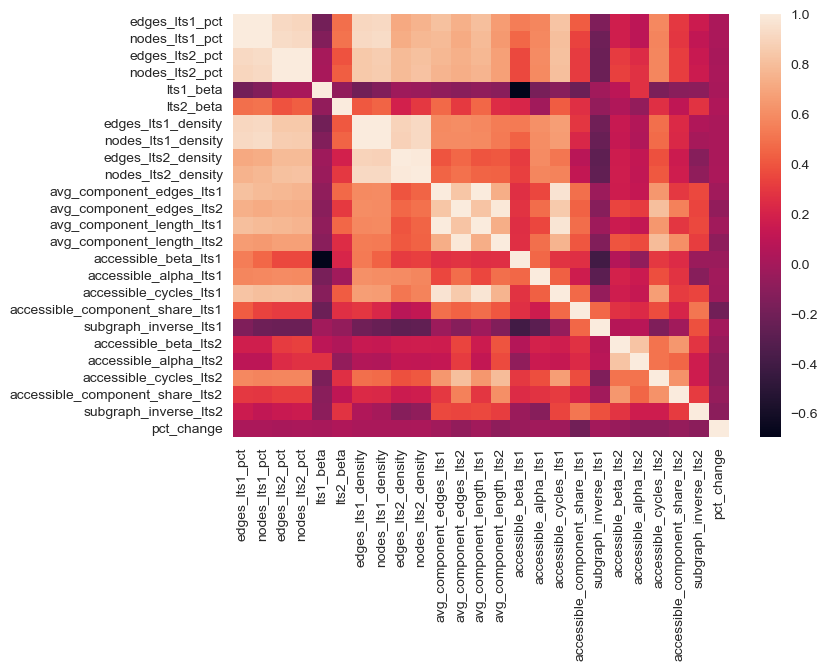

In [54]:
## I think the issue is that they all have too many 0 values
#filter out zero values

## Correlation with percentage change
ridership_quality_combined_nonzero=tracts[tracts[pct_bike_yr2]>0]
correlation=ridership_quality_combined_nonzero[np.append(quality_variable_columns,'pct_change')].corr()
sns.heatmap(correlation)

In [55]:
#highest correlation with percentage change
correlation['pct_change'].sort_values()

accessible_component_share_lts1   -0.200327
subgraph_inverse_lts2             -0.105457
accessible_alpha_lts2             -0.099539
accessible_cycles_lts2            -0.099515
avg_component_length_lts2         -0.089377
avg_component_edges_lts2          -0.076763
accessible_component_share_lts2   -0.061063
accessible_beta_lts2              -0.052089
accessible_beta_lts1              -0.045854
accessible_cycles_lts1            -0.025476
avg_component_edges_lts1          -0.020000
accessible_alpha_lts1             -0.017846
avg_component_length_lts1         -0.015710
subgraph_inverse_lts1             -0.013524
lts1_beta                          0.007033
edges_lts2_pct                     0.007247
nodes_lts2_pct                     0.013187
edges_lts1_density                 0.016997
nodes_lts1_density                 0.017781
edges_lts2_density                 0.019367
nodes_lts2_density                 0.021449
edges_lts1_pct                     0.022575
nodes_lts1_pct                  

In [56]:
#sns.pairplot(ridership_quality_combined_nonzero[np.append(quality_variable_columns,'pct_change')])

In [57]:
## table of highest correlation with current ridership?
correlation_2=ridership_quality_combined_nonzero[np.append(quality_variable_columns,pct_bike_yr2)].corr()
correlation_2[pct_bike_yr2].sort_values()

accessible_cycles_lts1            -0.123995
accessible_cycles_lts2            -0.123518
accessible_component_share_lts1   -0.101685
avg_component_length_lts1         -0.097946
accessible_alpha_lts2             -0.097675
avg_component_length_lts2         -0.095131
avg_component_edges_lts1          -0.094772
accessible_alpha_lts1             -0.094111
avg_component_edges_lts2          -0.093867
subgraph_inverse_lts2             -0.069739
nodes_lts2_pct                    -0.064834
edges_lts2_pct                    -0.062667
nodes_lts2_density                -0.048711
edges_lts2_density                -0.045336
accessible_component_share_lts2   -0.040333
accessible_beta_lts2              -0.040041
nodes_lts1_density                -0.025630
edges_lts1_density                -0.022610
accessible_beta_lts1              -0.020804
nodes_lts1_pct                    -0.019664
edges_lts1_pct                    -0.018056
lts2_beta                          0.014189
lts1_beta                       

Text(0.5, 0, 'network quality metric: accessible_beta_lts1')

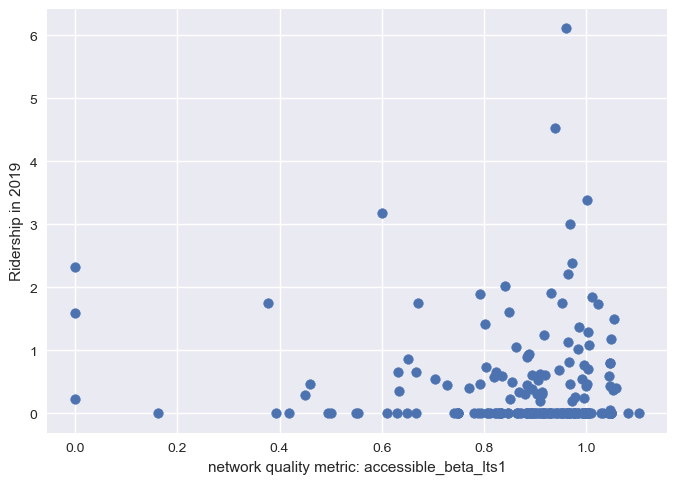

In [58]:
X=tracts[quality_variable_columns]
Y=tracts[[pct_bike_yr2,'pct_change']]

X_nonzero=ridership_quality_combined_nonzero[quality_variable_columns]
Y_nonzero=ridership_quality_combined_nonzero[[pct_bike_yr2,'pct_change']]

variable_to_use='accessible_beta_lts1' ## CHANGE THIS TO TRY OTHER QUALITY VARIABLES

plt.scatter(X[variable_to_use],Y[pct_bike_yr2])
plt.ylabel('Ridership in %s'%YEARS[1])
plt.xlabel('network quality metric: %s'%variable_to_use)

Text(0.5, 0, 'network quality metric: accessible_beta_lts1')

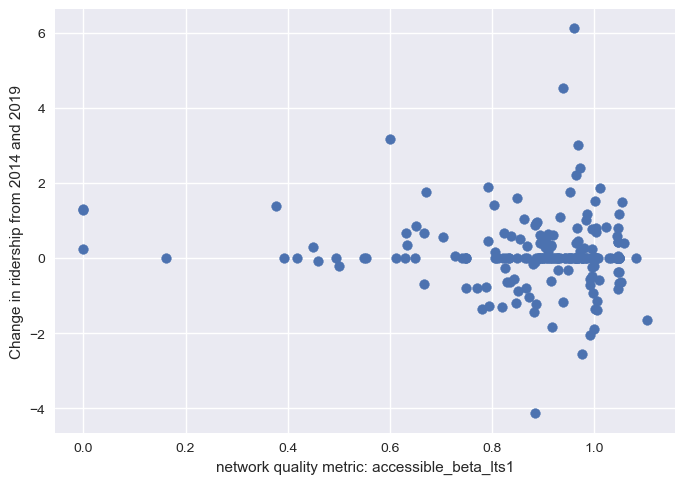

In [59]:
plt.scatter(X[variable_to_use],Y['pct_change'])
plt.ylabel('Change in ridership from %s and %s'%(YEARS[0],YEARS[1]))
plt.xlabel('network quality metric: %s'%variable_to_use)

Text(0.5, 0, 'network quality metric: accessible_beta_lts1')

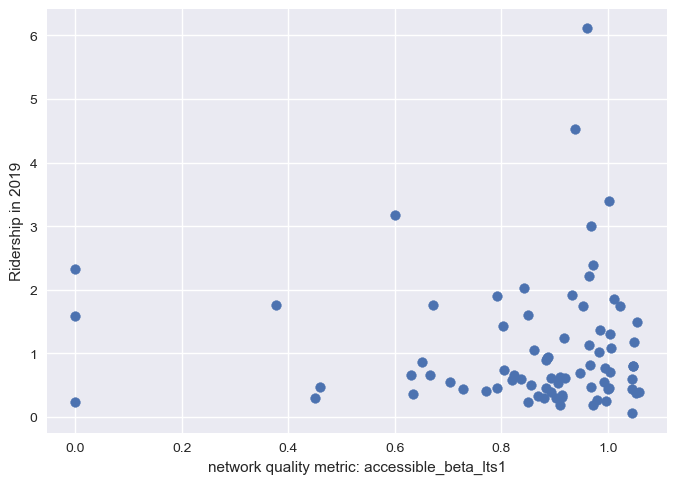

In [60]:
plt.scatter(X_nonzero[variable_to_use],Y_nonzero[pct_bike_yr2])
plt.ylabel('Ridership in %s'%YEARS[1])
plt.xlabel('network quality metric: %s'%variable_to_use)

Text(0.5, 0, 'network quality metric: accessible_beta_lts1')

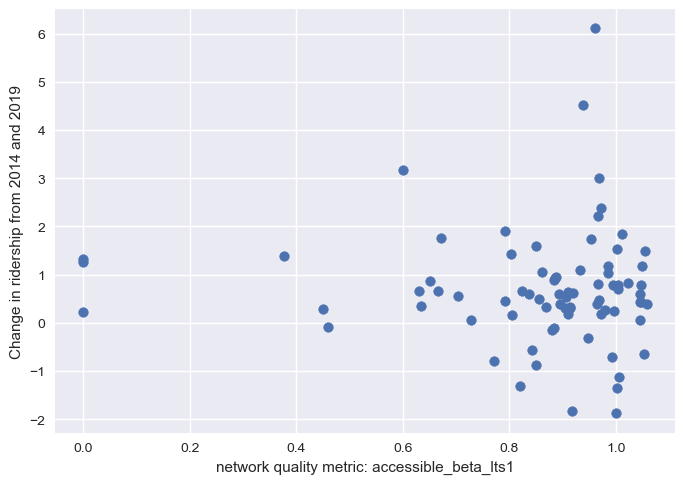

In [62]:
plt.scatter(X_nonzero[variable_to_use],Y_nonzero['pct_change'])
plt.ylabel('Change in ridership from %s and %s'%(YEARS[0],YEARS[1]))
plt.xlabel('network quality metric: %s'%variable_to_use)